In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
with open('../Excercises/18-Naive-Bayes-and-NLP/One.txt') as mytxt:
    words1 = mytxt.read().lower().split()
    uwords1 = set(words1)

In [17]:
with open('../Excercises/18-Naive-Bayes-and-NLP/Two.txt') as mytxt:
    words2 = mytxt.read().lower().split()
    uwords2 = set(words2)

In [18]:
print(uwords1,uwords2)

{'pets', 'this', 'a', 'canine', 'is', 'animals', 'dogs', 'furry', 'story', 'our', 'are', 'about'} {'this', 'surfing', 'a', 'is', 'waves', 'sport', 'water', 'catching', 'fun', 'story', 'about', 'popular'}


In [19]:
all_uni_words = set()
all_uni_words.update(uwords1)
all_uni_words.update(uwords2)

In [20]:
all_uni_words

{'a',
 'about',
 'animals',
 'are',
 'canine',
 'catching',
 'dogs',
 'fun',
 'furry',
 'is',
 'our',
 'pets',
 'popular',
 'sport',
 'story',
 'surfing',
 'this',
 'water',
 'waves'}

In [21]:
len(all_uni_words)

19

In [22]:
full_vocab = dict()
i = 0
for word in all_uni_words:
    full_vocab[word] = i
    i=i+1

In [24]:
full_vocab

{'pets': 0,
 'surfing': 1,
 'canine': 2,
 'is': 3,
 'waves': 4,
 'sport': 5,
 'catching': 6,
 'animals': 7,
 'our': 8,
 'popular': 9,
 'this': 10,
 'a': 11,
 'water': 12,
 'dogs': 13,
 'furry': 14,
 'fun': 15,
 'story': 16,
 'are': 17,
 'about': 18}

In [26]:
one_freq = [0]*len(full_vocab)
two_freq = [0]*len(full_vocab)
all_words = ['']*len(full_vocab)

In [29]:
for word in words1:
    word_ind = full_vocab[word]
    one_freq[word_ind] += 1
for word in words2:
    word_ind = full_vocab[word]
    two_freq[word_ind] += 1

In [32]:
one_freq,two_freq

([1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 2, 1, 0, 1, 1, 1],
 [0, 2, 0, 3, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1])

In [33]:
for word in full_vocab:
    word_ind = full_vocab[word]
    all_words[word_ind] = word

In [35]:
print(all_words)

['pets', 'surfing', 'canine', 'is', 'waves', 'sport', 'catching', 'animals', 'our', 'popular', 'this', 'a', 'water', 'dogs', 'furry', 'fun', 'story', 'are', 'about']


In [38]:
bow = pd.DataFrame(data=[one_freq,two_freq],columns=all_words)

In [40]:
bow

,pets,surfing,canine,is,waves,sport,catching,animals,our,popular,this,a,water,dogs,furry,fun,story,are,about
0,1,0,1,1,0,0,0,1,1,0,1,1,0,2,1,0,1,1,1
1,0,2,0,3,1,1,1,0,0,1,1,1,1,0,0,1,1,0,1


In [54]:
text = [
    'But I must explain to you how all this mistaken idea of complete account and praising pain was born',
    'I will give you a complete account of the system',
    'expound the actual teachings of the great explorer of the truth',
    'the master-builder of human happiness explorer.' 
]

In [67]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer

In [63]:
cv = CountVectorizer(stop_words='english')

In [64]:
vec_txt = cv.fit_transform(text)

In [65]:
vec_txt.todense()

matrix([[1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0],
        [1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1],
        [0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0]])

In [66]:
cv.vocabulary_

{'explain': 5,
 'mistaken': 13,
 'idea': 11,
 'complete': 4,
 'account': 0,
 'praising': 15,
 'pain': 14,
 'born': 2,
 'expound': 7,
 'actual': 1,
 'teachings': 16,
 'great': 8,
 'explorer': 6,
 'truth': 17,
 'master': 12,
 'builder': 3,
 'human': 10,
 'happiness': 9}

In [69]:
tfidf = TfidfTransformer()

In [72]:
tfidf.fit(vec_txt)

,"norm norm: {'l1', 'l2'} or None, default='l2'Each output row will have unit norm, either:- 'l2': Sum of squares of vector elements is 1. The cosine similarity between two vectors is their dot product when l2 norm has been applied.- 'l1': Sum of absolute values of vector elements is 1. See :func:`~sklearn.preprocessing.normalize`.- None: No normalization.",'l2'
,"use_idf use_idf: bool, default=TrueEnable inverse-document-frequency reweighting. If False, idf(t) = 1.",True
,"smooth_idf smooth_idf: bool, default=TrueSmooth idf weights by adding one to document frequencies, as if anextra document was seen containing every term in the collectionexactly once. Prevents zero divisions.",True
,"sublinear_tf sublinear_tf: bool, default=FalseApply sublinear tf scaling, i.e. replace tf with 1 + log(tf).",False


In [76]:
tfidf_vec = tfidf.transform(vec_txt)

In [79]:
tfidf_vec.todense()

matrix([[0.29294639, 0.        , 0.37156534, 0.        , 0.29294639,
         0.37156534, 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.37156534, 0.        , 0.37156534, 0.37156534,
         0.37156534, 0.        , 0.        ],
        [0.70710678, 0.        , 0.        , 0.        , 0.70710678,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.42176478, 0.        , 0.        , 0.        ,
         0.        , 0.3325242 , 0.42176478, 0.42176478, 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.42176478, 0.42176478],
        [0.        , 0.        , 0.        , 0.46516193, 0.        ,
         0.        , 0.36673901, 0.        , 0.        , 0.46516193,
         0.46516193, 0.        , 0.46516193, 0.        , 0.        ,
         0.        , 0.        , 0

In [81]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [86]:
tf = TfidfVectorizer(stop_words='english')

In [87]:
vec_tfidf = tf.fit_transform(text)

In [88]:
vec_tfidf.todense()

matrix([[0.29294639, 0.        , 0.37156534, 0.        , 0.29294639,
         0.37156534, 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.37156534, 0.        , 0.37156534, 0.37156534,
         0.37156534, 0.        , 0.        ],
        [0.70710678, 0.        , 0.        , 0.        , 0.70710678,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.42176478, 0.        , 0.        , 0.        ,
         0.        , 0.3325242 , 0.42176478, 0.42176478, 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.42176478, 0.42176478],
        [0.        , 0.        , 0.        , 0.46516193, 0.        ,
         0.        , 0.36673901, 0.        , 0.        , 0.46516193,
         0.46516193, 0.        , 0.46516193, 0.        , 0.        ,
         0.        , 0.        , 0

In [89]:
df = pd.read_csv('../Excercises/DATA/airline_tweets.csv')

In [90]:
df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


<Axes: xlabel='airline_sentiment', ylabel='count'>

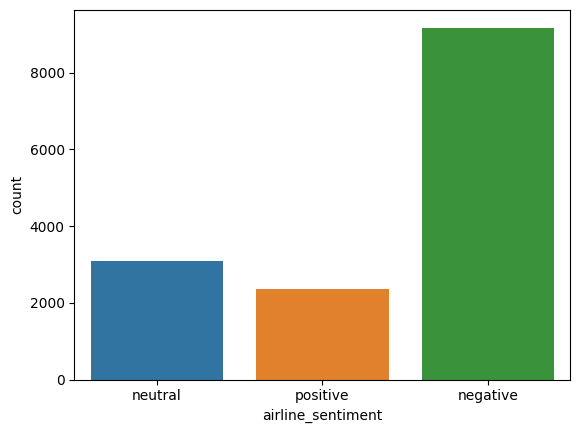

In [93]:
sns.countplot(data=df,x='airline_sentiment',hue='airline_sentiment')

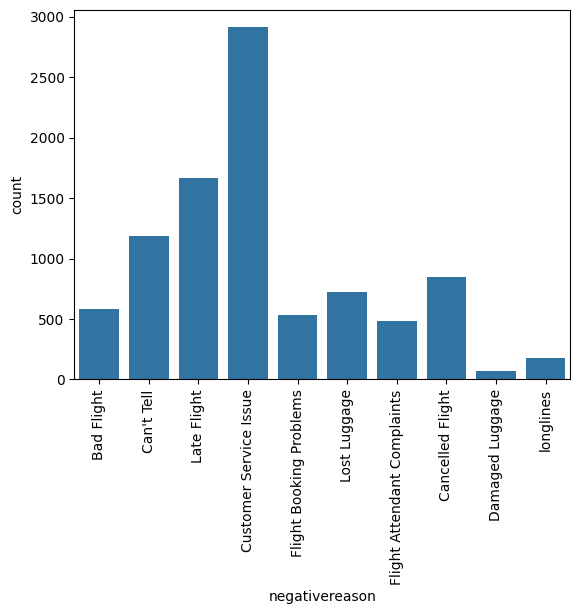

In [97]:
sns.countplot(data=df,x='negativereason')
plt.xticks(rotation=90);

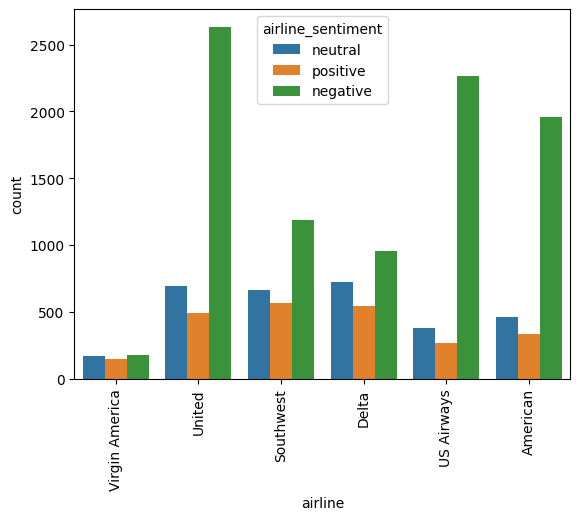

In [99]:
sns.countplot(data=df,x='airline',hue='airline_sentiment')
plt.xticks(rotation=90);

In [100]:
data = df[['airline_sentiment','text']]

In [102]:
data

,airline_sentiment,text
0,neutral,@VirginAmerica What @dhepburn said.
1,positive,@VirginAmerica plus you've added commercials t...
2,neutral,@VirginAmerica I didn't today... Must mean I n...
3,negative,@VirginAmerica it's really aggressive to blast...
4,negative,@VirginAmerica and it's a really big bad thing...
...,...,...
14635,positive,@AmericanAir thank you we got on a different f...
14636,negative,@AmericanAir leaving over 20 minutes Late Flig...
14637,neutral,@AmericanAir Please bring American Airlines to...
14638,negative,"@AmericanAir you have my money, you change my ..."


In [103]:
X = data['text']
Y = data['airline_sentiment']

In [104]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,Y,test_size=0.20,random_state=101)

In [105]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [107]:
tfidf = TfidfVectorizer(stop_words='english')

In [108]:
X_train = tfidf.fit_transform(X_train)

In [109]:
X_test = tfidf.transform(X_test)

In [114]:
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(X_train,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [115]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [118]:
from sklearn.svm import SVC,LinearSVC

In [119]:
svc = SVC()
lsvc = LinearSVC()

svc.fit(X_train,y_train)
lsvc.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [120]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [121]:
def report(model):
    preds = model.predict(X_test)
    print(classification_report(y_test,preds))
    ConfusionMatrixDisplay.from_estimator(model,X_test,y_test)

              precision    recall  f1-score   support

    negative       0.66      0.99      0.79      1817
     neutral       0.79      0.15      0.26       628
    positive       0.89      0.14      0.24       483

    accuracy                           0.67      2928
   macro avg       0.78      0.43      0.43      2928
weighted avg       0.73      0.67      0.59      2928



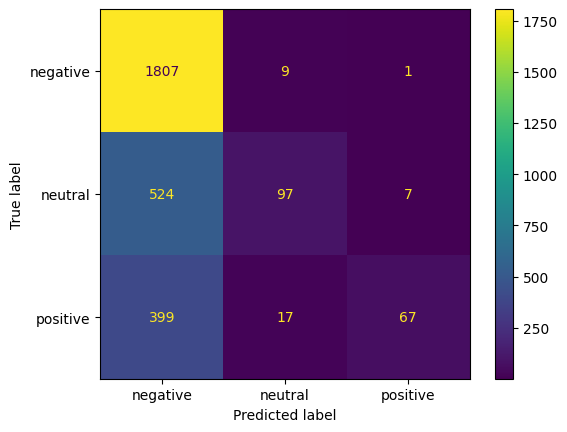

In [123]:
report(nb)

              precision    recall  f1-score   support

    negative       0.80      0.93      0.86      1817
     neutral       0.63      0.47      0.54       628
    positive       0.81      0.58      0.68       483

    accuracy                           0.77      2928
   macro avg       0.75      0.66      0.69      2928
weighted avg       0.77      0.77      0.76      2928



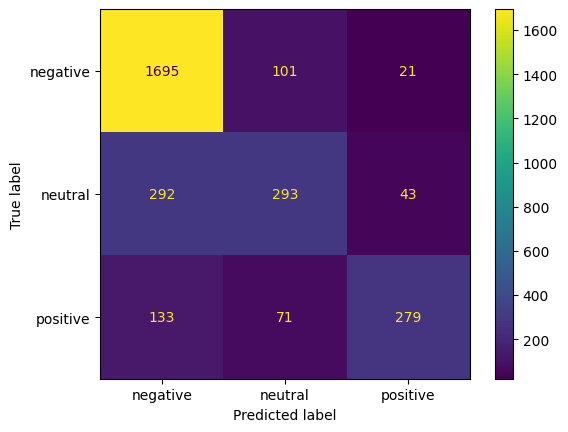

In [125]:
report(lr)

              precision    recall  f1-score   support

    negative       0.78      0.95      0.86      1817
     neutral       0.67      0.41      0.51       628
    positive       0.81      0.56      0.66       483

    accuracy                           0.77      2928
   macro avg       0.75      0.64      0.67      2928
weighted avg       0.76      0.77      0.75      2928



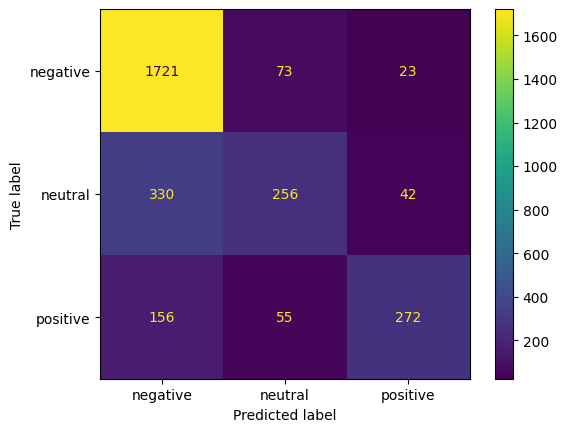

In [129]:
report(svc)

              precision    recall  f1-score   support

    negative       0.82      0.89      0.86      1817
     neutral       0.59      0.52      0.55       628
    positive       0.76      0.64      0.69       483

    accuracy                           0.77      2928
   macro avg       0.73      0.68      0.70      2928
weighted avg       0.76      0.77      0.77      2928



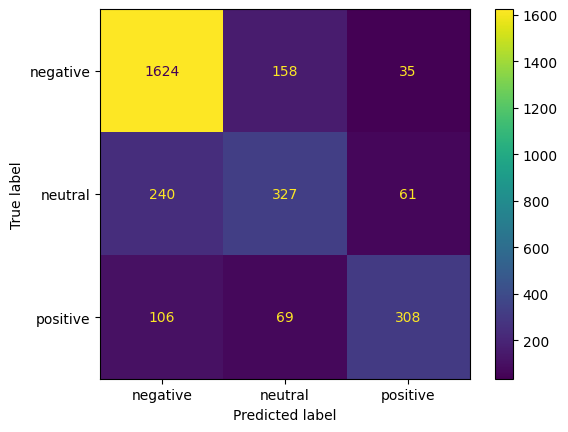

In [131]:
report(lsvc)

In [132]:
from sklearn.pipeline import Pipeline

pipe = Pipeline([
    ('tfidf',tfidf),
    ('svc',LinearSVC())
])

In [133]:
pipe.fit(X,Y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('tfidf', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


In [140]:
pipe.predict(['okay'])

array(['neutral'], dtype=object)